# 01 · Data preparation (DuckDB SQL) and exploratory analysis

**Business question:** How can a financial institution catch more fraudulent transactions without generating an unmanageable number of false alerts?

This notebook covers three things:
1. **Data prep in SQL (DuckDB):** cleaning, and behavioural features that only look backward in time (`sql/01_load_and_clean.sql`, `sql/02_behavioural_features.sql`).
2. **EDA:** where fraud concentrates by time, merchant category, geography, customer segment and amount (`sql/03_eda_segments.sql`).
3. **Time-based split:** train / validation / test by date, never random.

**Why DuckDB?** Fraud teams usually build features in the warehouse (SQL) and not in pandas. DuckDB runs the same window-function SQL you would run in Snowflake or BigQuery, on a laptop, in seconds.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from src import config, data, split, plotting, leakage
from src.features import NUMERIC_FEATURES, CATEGORICAL_FEATURES, DEMOGRAPHIC_FEATURES, FEATURE_LABELS
from src.plotting import takeaway

plotting.set_style()
pd.set_option("display.width", 160, "display.max_columns", 30)
np.random.seed(config.SEED)

## 1. Load, clean and engineer features in SQL

`data.build_database()` runs the SQL files in order and exports the feature table to `data/processed/features.parquet`. It is idempotent: if the parquet already exists it is reused. Pass `force=True` to rebuild.

What the cleaning SQL does, and why:
- **Reads everything as text, then casts explicitly** with `TRY_CAST`. That way card numbers are never parsed as floats, zip codes keep their leading zeros, and bad values become NULLs we can count instead of silent errors.
- **De-duplicates** on transaction ID, and on (card, timestamp, merchant, amount) to catch double-posted records.
- **Drops rows that can't be scored or evaluated** (no timestamp, card, amount or label). It fills descriptive fields with explicit `UNKNOWN` categories rather than guessing a value.
- **Removes fields with no legitimate role:** customer names and street (synthetic PII), plus the raw row index. It also strips the simulator's `fraud_` prefix from merchant names. Every merchant has that prefix, so it is not a label, but it would read badly in a case report.

In [2]:
data.build_database()
display(data.run_query("SELECT * FROM cleaning_audit"))
display(data.run_query("SELECT * FROM missing_audit ORDER BY column_name"))

,step,n_rows
0,raw rows,1852394
1,after type casting,1852394
2,after de-duplication,1852394
3,after dropping unusable rows,1852394


,column_name,n_missing
0,amt,0
1,category,0
2,cc_num,0
3,city_pop,0
4,cust_lat,0
5,dob,0
6,gender,0
7,is_fraud,0
8,merch_lat,0
9,merchant,0


In [3]:
df = data.load_features()
n_rows, fraud_rate = len(df), df.is_fraud.mean()
facts = pd.Series({
    "Transactions": f"{n_rows:,}",
    "Fraudulent transactions": f"{int(df.is_fraud.sum()):,}",
    "Fraud rate": f"{fraud_rate:.3%}",
    "Legit : fraud ratio": f"{(1 - fraud_rate) / fraud_rate:.0f} : 1",
    "Fraud dollar share": f"{df.loc[df.is_fraud == 1, 'amt'].sum() / df.amt.sum():.2%}",
    "Date range": f"{df.ts.min():%Y-%m-%d} to {df.ts.max():%Y-%m-%d}",
    "Cards (customers)": f"{df.cc_num.nunique():,}",
    "Merchants": f"{df.merchant.nunique():,}",
    "Merchant categories": f"{df.category.nunique()}",
    "Avg transactions per day": f"{n_rows / df.ts.dt.normalize().nunique():,.0f}",
}, name="value")
facts.to_frame().to_csv(config.REPORTS / "dataset_facts.csv")
facts.to_frame()

,value
Transactions,"1,852,394"
Fraudulent transactions,"9,651"
Fraud rate,0.521%
Legit : fraud ratio,191 : 1
Fraud dollar share,3.95%
Date range,2019-01-01 to 2020-12-31
Cards (customers),999
Merchants,693
Merchant categories,14
Avg transactions per day,"2,538"


### Missing values

The raw data has no missing values in any column (audit above). The only NULLs come from engineered history features, and they are there **by design**: a card's first transaction has no prior average, and a zero-variance history has no z-score. We keep them as NULL in SQL, because "no history yet" is informative. The model preprocessing then handles them with training-fitted imputation plus missing flags, or natively in LightGBM.

In [4]:
na = df.isna().sum()
na = na[na > 0].rename("n_missing").to_frame()
na["pct"] = (na.n_missing / len(df) * 100).round(3)
na["reason"] = "no prior history for this card / category (structural, not data quality)"
na

,n_missing,pct,reason
cust_avg_amt_prior,999,0.054,no prior history for this card / category (str...
amt_to_cust_avg,999,0.054,no prior history for this card / category (str...
amt_zscore_cust,1998,0.108,no prior history for this card / category (str...
amt_to_cust_avg_7d,1318,0.071,no prior history for this card / category (str...
amt_to_cust_category_avg,13171,0.711,no prior history for this card / category (str...
hours_since_last_txn,999,0.054,no prior history for this card / category (str...


## 2. Exploratory analysis

The charts below are all computed with SQL in `sql/03_eda_segments.sql`. EDA runs on the full two years to describe the data. **Modelling decisions, such as rule cut-offs, are made on the training split only** (notebook 02).

In [5]:
seg = data.run_sql_file("03_eda_segments.sql")
overall = fraud_rate * 100
seg["class_balance"]

,is_fraud,transactions,pct,amount_usd
0,0,1842743,99.479,124663919.0
1,1,9651,0.521,5121413.0


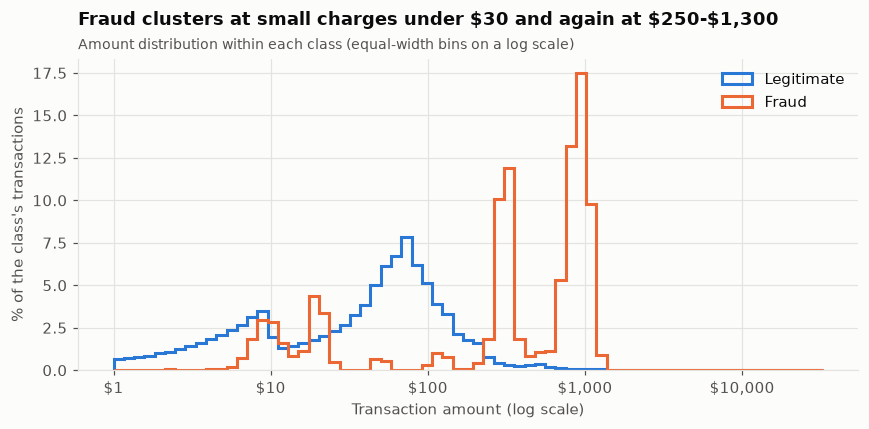

**Takeaway:** Median fraud amount is \$390 vs \$47 for legitimate transactions. 21% of frauds are under \$30 and 75% are \$250+, so a 'high amount' rule alone will miss a large share of cases.

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, np.log10(df.amt.max()) + 0.05, 70)
for lab, cls, col in [("Legitimate", 0, plotting.BLUE), ("Fraud", 1, plotting.ORANGE)]:
    x = np.log10(df.loc[df.is_fraud == cls, "amt"])
    ax.hist(x, bins=bins, weights=np.full(len(x), 100 / len(x)), histtype="step", lw=2, color=col, label=lab)
ticks = [1, 10, 100, 1000, 10000]
ax.set_xticks(np.log10(ticks), [f"${t:,}" for t in ticks])
ax.set_xlabel("Transaction amount (log scale)"); ax.set_ylabel("% of the class's transactions")
med_f, med_l = df.loc[df.is_fraud == 1, "amt"].median(), df.loc[df.is_fraud == 0, "amt"].median()
plotting.title(ax, "Fraud clusters at small charges under $30 and again at $250-$1,300",
               "Amount distribution within each class (equal-width bins on a log scale)")
ax.legend()
plotting.save(fig, "eda_amount_distribution"); plt.show()
f_amt = df.loc[df.is_fraud == 1, "amt"]
takeaway(f"Median fraud amount is \${med_f:,.0f} vs \${med_l:,.0f} for legitimate transactions. "
         f"{(f_amt < 30).mean():.0%} of frauds are under \$30 and {(f_amt >= 250).mean():.0%} are \$250+, "
         "so a 'high amount' rule alone will miss a large share of cases.")

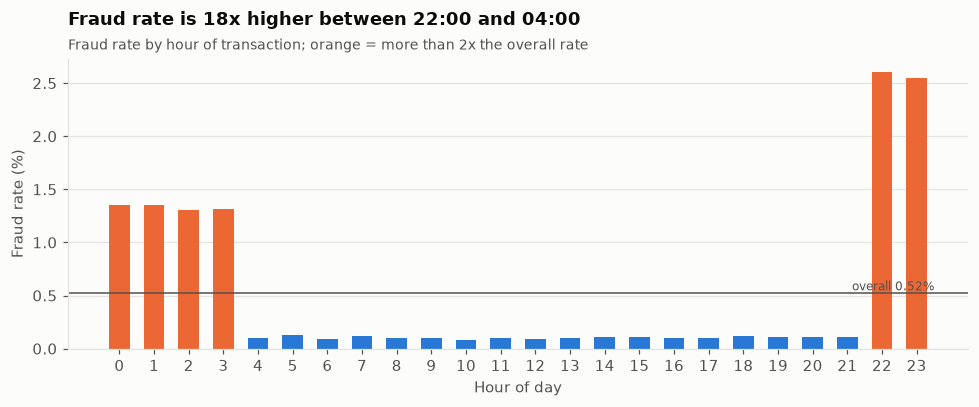

**Takeaway:** 85% of all frauds happen in the 22:00-04:00 window, which holds only 23% of transactions.

In [7]:
h = seg["by_hour"]
fig, ax = plt.subplots(figsize=(9, 3.8))
plotting.rate_bars(ax, h.hour, h.fraud_rate_pct, overall, highlight=lambda l, r: r > 2 * overall)
ax.set_xlabel("Hour of day"); ax.set_ylabel("Fraud rate (%)")
night = df[df.is_night == 1]
night_rate, day_rate = df[df.is_night == 1].is_fraud.mean(), df[df.is_night == 0].is_fraud.mean()
plotting.title(ax, f"Fraud rate is {night_rate / day_rate:.0f}x higher between 22:00 and 04:00",
               "Fraud rate by hour of transaction; orange = more than 2x the overall rate")
plotting.save(fig, "eda_fraud_by_hour"); plt.show()
takeaway(f"{night.is_fraud.sum() / df.is_fraud.sum():.0%} of all frauds happen in the 22:00-04:00 window, "
         f"which holds only {len(night) / len(df):.0%} of transactions.")

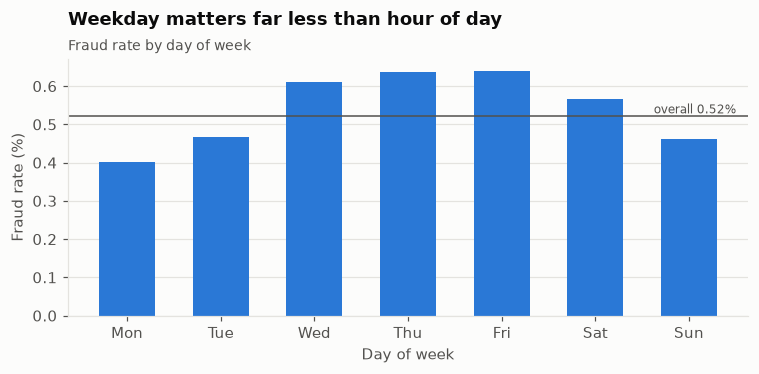

**Takeaway:** Fraud rate ranges only from 0.40% to 0.64% across weekdays; fraud counts per weekday vary less (1,125-1,590) than transaction volume (183,913-369,418), so the midweek bump is mostly a volume effect.

In [8]:
w = seg["by_weekday"].copy()
w["day"] = w.day_of_week.map(dict(enumerate(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], start=1)))
fig, ax = plt.subplots(figsize=(7, 3.5))
plotting.rate_bars(ax, w.day, w.fraud_rate_pct, overall)
ax.set_xlabel("Day of week"); ax.set_ylabel("Fraud rate (%)")
plotting.title(ax, "Weekday matters far less than hour of day",
               "Fraud rate by day of week")
plotting.save(fig, "eda_fraud_by_weekday"); plt.show()
takeaway(f"Fraud rate ranges only from {w.fraud_rate_pct.min():.2f}% to {w.fraud_rate_pct.max():.2f}% across weekdays; "
         f"fraud counts per weekday vary less ({w.frauds.min():,.0f}-{w.frauds.max():,.0f}) than transaction volume "
         f"({w.transactions.min():,}-{w.transactions.max():,}), so the midweek bump is mostly a volume effect.")

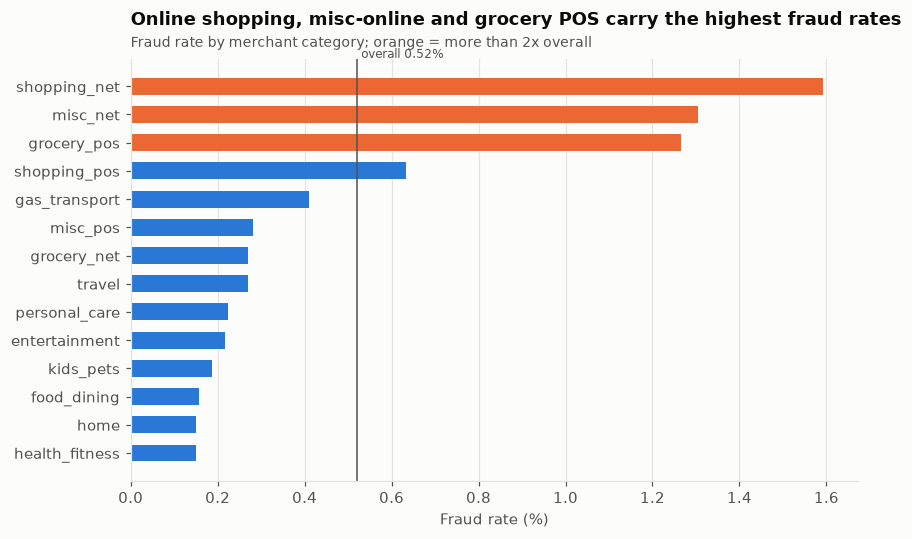

**Takeaway:** The top 3 categories (shopping_net, misc_net, grocery_pos) hold 58% of fraud cases and 75% of fraud dollars.

,category,transactions,frauds,fraud_rate_pct,fraud_amount_usd,median_fraud_amt
0,shopping_net,139322,2219.0,1.593,2214848.0,994.15
1,misc_net,90654,1182.0,1.304,944010.0,794.21
2,grocery_pos,176191,2228.0,1.265,695665.0,310.24
3,shopping_pos,166463,1056.0,0.634,928132.0,869.92
4,gas_transport,188029,772.0,0.411,9443.0,10.64
5,misc_pos,114229,322.0,0.282,68495.0,9.10
6,grocery_net,64878,175.0,0.270,2108.0,12.10
7,travel,57956,156.0,0.269,1399.0,9.70
8,personal_care,130085,290.0,0.223,7572.0,20.97
9,entertainment,134118,292.0,0.218,147400.0,500.84


In [9]:
c = seg["by_category"]
fig, ax = plt.subplots(figsize=(8, 5))
plotting.rate_bars(ax, c.category, c.fraud_rate_pct, overall, horizontal=True, highlight=lambda l, r: r > 2 * overall)
ax.set_xlabel("Fraud rate (%)")
plotting.title(ax, "Online shopping, misc-online and grocery POS carry the highest fraud rates",
               "Fraud rate by merchant category; orange = more than 2x overall")
plotting.save(fig, "eda_fraud_by_category"); plt.show()
top3 = c.head(3)
takeaway(f"The top 3 categories ({', '.join(top3.category)}) hold {top3.frauds.sum() / c.frauds.sum():.0%} of fraud cases "
         f"and {top3.fraud_amount_usd.sum() / c.fraud_amount_usd.sum():.0%} of fraud dollars.")
display(c)

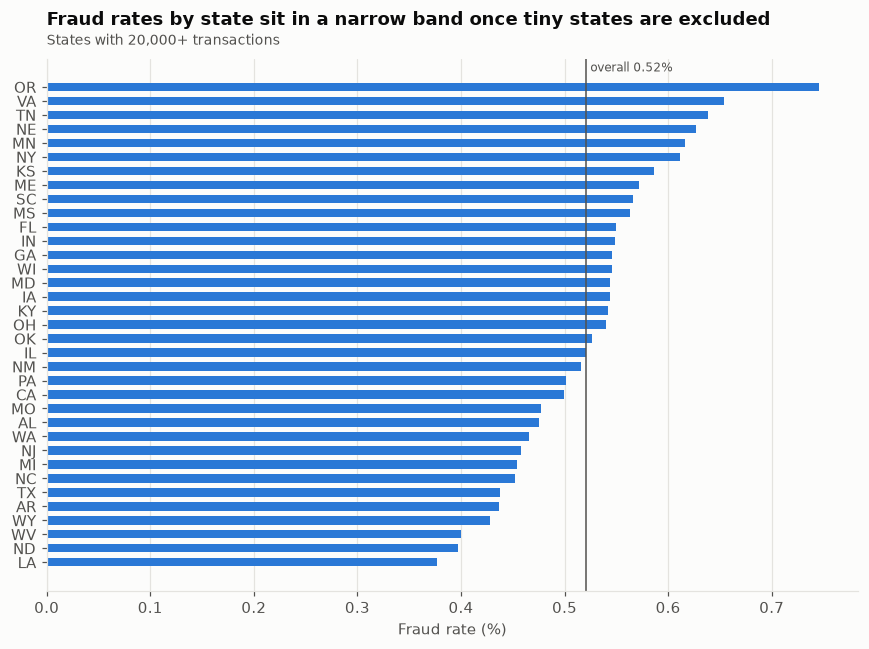

**Takeaway:** Across states with 20k+ transactions the rate spans 0.38%-0.75%. 4 states have 3 or fewer customers, so their rates reflect individual cards rather than geography. This is why state is used for segment analysis, not as a model feature.

In [10]:
s = seg["by_state"]
s_big = s[s.transactions >= 20000].sort_values("fraud_rate_pct", ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
plotting.rate_bars(ax, s_big.state, s_big.fraud_rate_pct, overall, horizontal=True)
ax.set_xlabel("Fraud rate (%)")
plotting.title(ax, "Fraud rates by state sit in a narrow band once tiny states are excluded",
               "States with 20,000+ transactions")
plotting.save(fig, "eda_fraud_by_state"); plt.show()
small = s[s.customers <= 3]
takeaway(f"Across states with 20k+ transactions the rate spans {s_big.fraud_rate_pct.min():.2f}%-{s_big.fraud_rate_pct.max():.2f}%. "
         f"{len(small)} states have 3 or fewer customers, so their rates reflect individual cards rather than geography. "
         "This is why state is used for segment analysis, not as a model feature.")

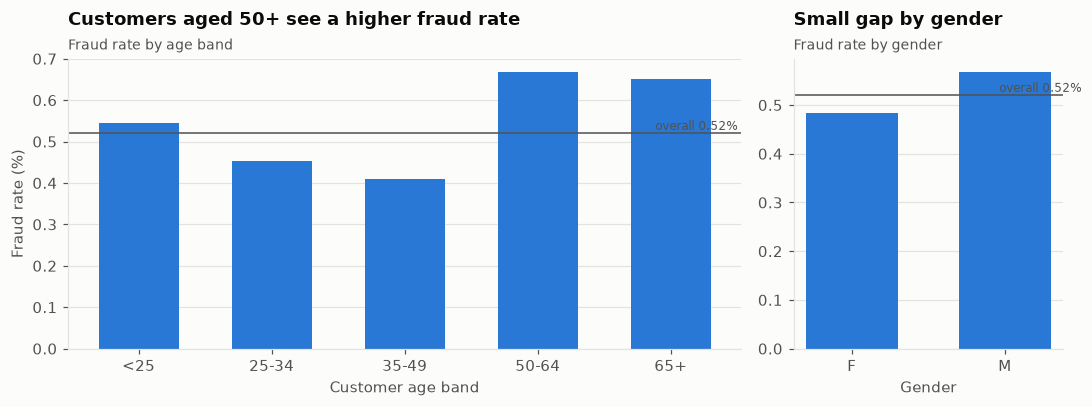

**Takeaway:** Ages 50+ have a 0.66% fraud rate vs 0.44% under 50. Age and gender are protected characteristics, so they are left out of the production model and tested only in an ablation (notebook 04).

In [11]:
a, g = seg["by_age_band"], seg["by_gender"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), gridspec_kw={"width_ratios": [5, 2]})
plotting.rate_bars(axes[0], a.age_band.str[3:], a.fraud_rate_pct, overall)
axes[0].set_xlabel("Customer age band"); axes[0].set_ylabel("Fraud rate (%)")
plotting.title(axes[0], "Customers aged 50+ see a higher fraud rate", "Fraud rate by age band")
plotting.rate_bars(axes[1], g.gender, g.fraud_rate_pct, overall)
axes[1].set_xlabel("Gender")
plotting.title(axes[1], "Small gap by gender", "Fraud rate by gender")
plotting.save(fig, "eda_fraud_by_customer_segment"); plt.show()
takeaway(f"Ages 50+ have a {a[a.age_band.str.startswith(('4', '5'))].frauds.sum() / a[a.age_band.str.startswith(('4', '5'))].transactions.sum():.2%} fraud rate "
         f"vs {a[~a.age_band.str.startswith(('4', '5'))].frauds.sum() / a[~a.age_band.str.startswith(('4', '5'))].transactions.sum():.2%} under 50. "
         "Age and gender are protected characteristics, so they are left out of the production model and tested only in an ablation (notebook 04).")

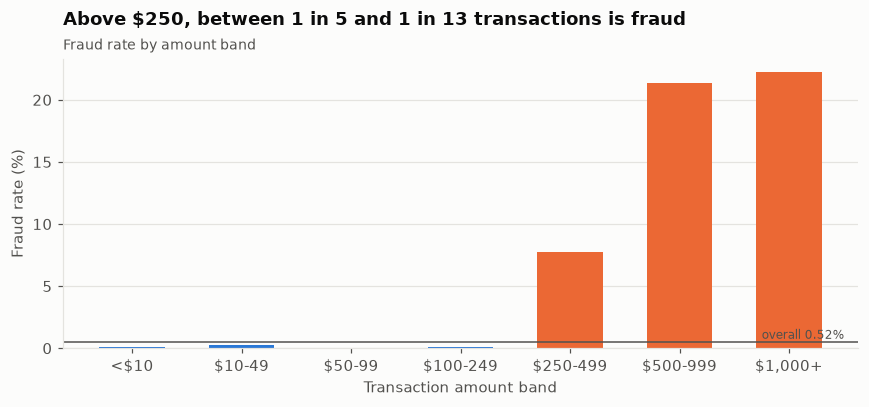

**Takeaway:** Transactions of $250+ are 2.9% of volume but 75% of frauds.

In [12]:
b = seg["by_amount_band"]
fig, ax = plt.subplots(figsize=(8, 3.8))
plotting.rate_bars(ax, b.amount_band.str[3:], b.fraud_rate_pct, overall, highlight=lambda l, r: r > 2 * overall)
ax.set_xlabel("Transaction amount band"); ax.set_ylabel("Fraud rate (%)")
hi = b[b.amount_band.str.startswith(("5", "6", "7"))]
plotting.title(ax, f"Above $250, between 1 in {100 / hi.fraud_rate_pct.max():.0f} and 1 in {100 / hi.fraud_rate_pct.min():.0f} transactions is fraud",
               "Fraud rate by amount band")
plotting.save(fig, "eda_fraud_by_amount_band"); plt.show()
hi = b[b.amount_band.str.startswith(("5", "6", "7"))]
takeaway(f"Transactions of $250+ are {hi.transactions.sum() / b.transactions.sum():.1%} of volume but {hi.frauds.sum() / b.frauds.sum():.0%} of frauds.")

### Fraud comes in bursts on compromised cards

Almost every card experiences a fraud episode: several fraudulent transactions over a day or two. This is the pattern **velocity features** are designed to catch. It is also why a **random** train/test split would leak: transactions from the same burst would land on both sides.

In [13]:
seg["frauds_per_card"]

,cards_with_fraud,avg_frauds_per_compromised_card,median_frauds_per_compromised_card,avg_fraud_span_hours,median_fraud_span_hours
0,976,9.9,10.0,40.7,45.258333


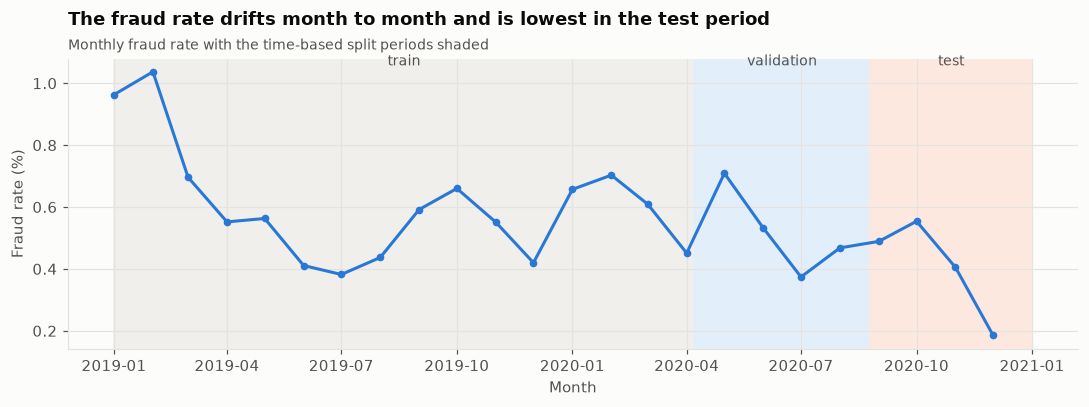

**Takeaway:** Monthly fraud rate ranges from 0.18% to 1.04%. December volume roughly doubles while fraud does not, so precision is expected to fall in the test period.

In [14]:
m = seg["monthly"].copy(); m["month"] = pd.to_datetime(m["month"])
val_start, test_start = split.compute_cutoffs(df.ts)
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(m.month, m.fraud_rate_pct, color=plotting.BLUE, marker="o", ms=4)
for x0, x1, lab in [(m.month.min(), val_start, "train"), (val_start, test_start, "validation"), (test_start, df.ts.max(), "test")]:
    ax.axvspan(x0, x1, color={"train": "#f0efec", "validation": "#e3eefb", "test": "#fde8df"}[lab], zorder=0)
    ax.text(x0 + (x1 - x0) / 2, m.fraud_rate_pct.max() * 1.02, lab, ha="center", color=plotting.TEXT_2, fontsize=9)
ax.set_ylabel("Fraud rate (%)"); ax.set_xlabel("Month")
plotting.title(ax, "The fraud rate drifts month to month and is lowest in the test period",
               "Monthly fraud rate with the time-based split periods shaded")
plotting.save(fig, "eda_monthly_fraud_rate"); plt.show()
takeaway(f"Monthly fraud rate ranges from {m.fraud_rate_pct.min():.2f}% to {m.fraud_rate_pct.max():.2f}%. "
         "December volume roughly doubles while fraud does not, so precision is expected to fall in the test period.")

## 3. Feature list

Every feature is available **at authorisation time** and uses only earlier transactions on the same card. Features are grouped by the fraud behaviour they target.

In [15]:
groups = {
    "Transaction": ["log_amt", "category", "hour", "day_of_week", "is_night"],
    "Velocity (backward windows)": ["n_txn_prior_1h", "amt_sum_prior_1h", "n_txn_prior_24h", "amt_sum_prior_24h", "n_txn_prior_7d"],
    "Deviation from the customer's norm": ["amt_to_cust_avg", "amt_zscore_cust", "amt_to_cust_avg_7d", "amt_to_cust_category_avg"],
    "Recency and novelty": ["hours_since_last_txn", "is_first_merchant_for_cust", "is_first_category_for_cust", "cust_n_prior_txn"],
    "Customer context": ["log_city_pop", "dist_home_merchant_km"],
    "Demographic (ablation only, not in production model)": DEMOGRAPHIC_FEATURES,
}
feat_table = pd.DataFrame([(g, f, FEATURE_LABELS[f]) for g, fs in groups.items() for f in fs],
                          columns=["group", "feature", "description"])
feat_table.to_csv(config.REPORTS / "feature_list.csv", index=False)
assert set(feat_table.feature) == set(NUMERIC_FEATURES + CATEGORICAL_FEATURES + DEMOGRAPHIC_FEATURES)
feat_table

,group,feature,description
0,Transaction,log_amt,Transaction amount (log)
1,Transaction,category,Merchant category
2,Transaction,hour,Hour of day
3,Transaction,day_of_week,Day of week
4,Transaction,is_night,Night-time (22:00-04:00)
5,Velocity (backward windows),n_txn_prior_1h,Card transactions in prior 1h
6,Velocity (backward windows),amt_sum_prior_1h,Card spend in prior 1h ($)
7,Velocity (backward windows),n_txn_prior_24h,Card transactions in prior 24h
8,Velocity (backward windows),amt_sum_prior_24h,Card spend in prior 24h ($)
9,Velocity (backward windows),n_txn_prior_7d,Card transactions in prior 7d


### Leakage check: recompute the SQL window features independently

The SQL windows end at `1 PRECEDING` on an epoch-second key. To prove they never look ahead, we recompute three of them in NumPy for 25 random cards, using only strictly earlier timestamps, and compare row by row. `tests/test_leakage.py` also perturbs a *future* transaction and asserts that no earlier feature changes.

In [16]:
rng = np.random.default_rng(config.SEED)
cards = list(rng.choice(df.cc_num.unique(), size=25, replace=False))
chk = leakage.compare_with_sql(df, cards)
assert chk.mismatches.sum() == 0, "window features disagree with independent recomputation"
chk

,feature,rows_checked,mismatches
0,n_txn_prior_1h,44641,0
1,n_txn_prior_24h,44641,0
2,cust_avg_amt_prior,44641,0


In [17]:
tr_mask = df.ts < val_start
sig = []
for f, bins, labels in [
    ("n_txn_prior_24h", [-1, 2, 5, 10, 1e9], ["0-2", "3-5", "6-10", "11+"]),
    ("amt_to_cust_avg", [-1, 1, 3, 10, 1e9], ["<=1x", "1-3x", "3-10x", ">10x"]),
    ("hours_since_last_txn", [-1, 0.25, 1, 6, 1e9], ["<15m", "15m-1h", "1-6h", ">6h"]),
]:
    t = df.loc[tr_mask, [f, "is_fraud"]].copy()
    t["bin"] = pd.cut(t[f], bins=bins, labels=labels)
    r = t.groupby("bin", observed=True).is_fraud.agg(["size", "mean"]).reset_index()
    r.insert(0, "feature", f); sig.append(r)
sig = pd.concat(sig).rename(columns={"size": "transactions", "mean": "fraud_rate"})
sig["fraud_rate"] = (sig.fraud_rate * 100).round(3)
sig

,feature,bin,transactions,fraud_rate
0,n_txn_prior_24h,0-2,430604,0.377
1,n_txn_prior_24h,3-5,409564,0.720
2,n_txn_prior_24h,6-10,226829,0.768
3,n_txn_prior_24h,11+,43693,0.172
0,amt_to_cust_avg,<=1x,746462,0.203
1,amt_to_cust_avg,1-3x,317440,0.209
2,amt_to_cust_avg,3-10x,38324,5.451
3,amt_to_cust_avg,>10x,7495,27.432
0,hours_since_last_txn,<15m,51427,2.088
1,hours_since_last_txn,15m-1h,131612,1.301


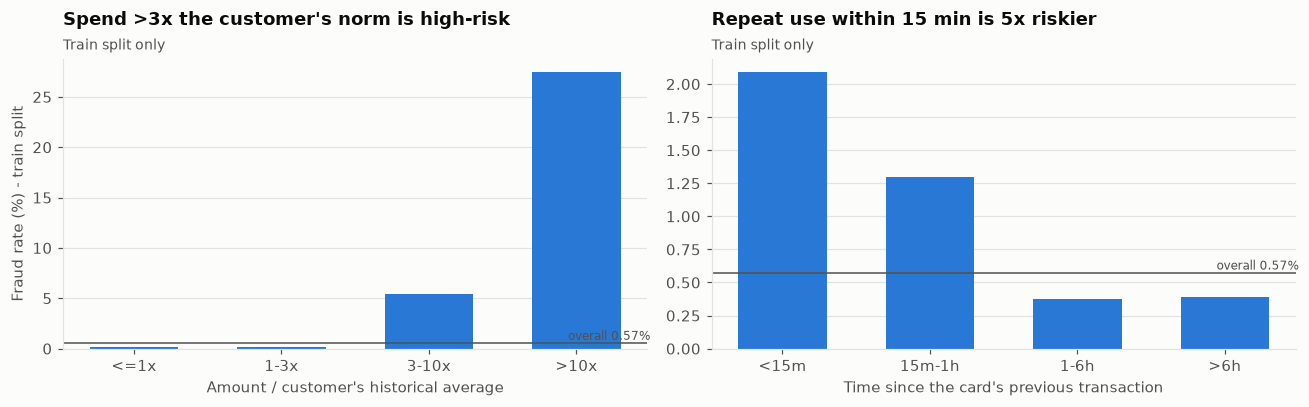

**Takeaway:** On the training split, transactions above 10x the customer's average are fraud 27.4% of the time vs 0.20% at or below their average. 24h velocity is non-monotonic (11+ prior transactions: 0.17%, busy legitimate days), so it works best in combination with other features, which is the case for a model over single rules.

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
s1 = sig[sig.feature == "amt_to_cust_avg"]
plotting.rate_bars(axes[0], s1.bin, s1.fraud_rate, df.loc[tr_mask].is_fraud.mean() * 100)
axes[0].set_xlabel("Amount / customer's historical average"); axes[0].set_ylabel("Fraud rate (%) - train split")
plotting.title(axes[0], "Spend >3x the customer's norm is high-risk", "Train split only")
s2 = sig[sig.feature == "hours_since_last_txn"]
plotting.rate_bars(axes[1], s2.bin, s2.fraud_rate, df.loc[tr_mask].is_fraud.mean() * 100)
axes[1].set_xlabel("Time since the card's previous transaction")
plotting.title(axes[1], f"Repeat use within 15 min is {s2.fraud_rate.iloc[0] / s2.fraud_rate.iloc[-1]:.0f}x riskier", "Train split only")
plotting.save(fig, "eda_behavioural_signal"); plt.show()
s3 = sig[sig.feature == "n_txn_prior_24h"]
takeaway(f"On the training split, transactions above 10x the customer's average are fraud "
         f"{s1.fraud_rate.iloc[-1]:.1f}% of the time vs {s1.fraud_rate.iloc[0]:.2f}% at or below their average. "
         f"24h velocity is non-monotonic (11+ prior transactions: {s3.fraud_rate.iloc[-1]:.2f}%, busy legitimate days), "
         "so it works best in combination with other features, which is the case for a model over single rules.")

## 4. Time-based split (60 / 20 / 20)

- **Train** is the earliest 60% of transactions. **Validation** is the next 20%, used for model selection, tuning and choosing thresholds. **Test** is the latest 20%, touched **once** at the end.
- Cut-offs are the 60th and 80th percentiles of transaction time, snapped to midnight so that no day is split.
- **Why not random?** Production scores the future using a model trained on the past. A random split would put transactions from the same fraud burst in both train and test, and overstate performance.
- Everything fitted (imputers, encoders, scalers, resamplers, rule cut-offs) is fitted on train only.

In [19]:
df["split"] = split.assign_split(df, val_start, test_start)
summary = split.summarise(df)
summary.to_csv(config.REPORTS / "split_summary.csv")
df[["trans_num", "split"]].to_parquet(config.DATA_PROCESSED / "splits.parquet", index=False)
print(f"Validation starts {val_start:%Y-%m-%d}; test starts {test_start:%Y-%m-%d}")
summary

Validation starts 2020-04-07; test starts 2020-08-25


,start,end,days,transactions,frauds,fraud_rate_pct,fraud_amount_usd,share_of_rows_pct
split,,,,,,,,
train,2019-01-01,2020-04-06,461,1110690,6386,0.575,3392366.0,60.0
validation,2020-04-07,2020-08-24,140,371005,1907,0.514,990992.0,20.0
test,2020-08-25,2020-12-31,129,370699,1358,0.366,738055.0,20.0


In [20]:
# Sanity checks on the split
assert df.groupby("split").ts.max()["train"] < df.groupby("split").ts.min()["validation"]
assert df.groupby("split").ts.max()["validation"] < df.groupby("split").ts.min()["test"]
new_cards_test = set(df[df.split == "test"].cc_num) - set(df[df.split == "train"].cc_num)
print(f"Cards in test not seen in train: {len(new_cards_test)} "
      f"({df[df.cc_num.isin(new_cards_test) & (df.split == 'test')].shape[0]:,} test transactions)")

Cards in test not seen in train: 12 (126 test transactions)


In [21]:
tr, va, te = summary.loc["train"], summary.loc["validation"], summary.loc["test"]
takeaway(f"Test-period fraud rate ({te.fraud_rate_pct:.3f}%) is lower than train ({tr.fraud_rate_pct:.3f}%), "
         f"so a threshold tuned on older data will produce more false alerts per fraud caught. "
         "This is why thresholds are set on validation and re-checked on test, and monitored monthly (notebook 05).")

**Takeaway:** Test-period fraud rate (0.366%) is lower than train (0.575%), so a threshold tuned on older data will produce more false alerts per fraud caught. This is why thresholds are set on validation and re-checked on test, and monitored monthly (notebook 05).

In [22]:
# Key EDA facts quoted in the README (written here so the docs never hard-code them)
hi_amt = df.amt >= 250
eda_facts = {
    "night_share_of_fraud": float(df[df.is_night == 1].is_fraud.sum() / df.is_fraud.sum()),
    "night_share_of_volume": float(df.is_night.mean()),
    "night_vs_day_fraud_rate_ratio": float(night_rate / day_rate),
    "amt250_share_of_volume": float(hi_amt.mean()),
    "amt250_share_of_fraud": float(df[hi_amt].is_fraud.sum() / df.is_fraud.sum()),
    "top3_categories": list(c.head(3).category),
    "top3_category_share_of_fraud_usd": float(c.head(3).fraud_amount_usd.sum() / c.fraud_amount_usd.sum()),
}
import json
(config.REPORTS / "eda_key_facts.json").write_text(json.dumps(eda_facts, indent=2))
eda_facts

{'night_share_of_fraud': 0.8464407833385141,
 'night_share_of_volume': 0.23484258748408815,
 'night_vs_day_fraud_rate_ratio': 17.959515877808567,
 'amt250_share_of_volume': 0.029109897786324074,
 'amt250_share_of_fraud': 0.745207750492177,
 'top3_categories': ['shopping_net', 'misc_net', 'grocery_pos'],
 'top3_category_share_of_fraud_usd': 0.7526286685669231}

## Summary

- The data is clean. It has no duplicates and no missing raw values. The only NULLs are structural ones from the history features, which the model preprocessing handles.
- Fraud concentrates in **night hours**, **online shopping, misc-online and grocery POS**, **amounts of $250+**, and **bursts on a compromised card**. That motivates the time, amount and velocity features, plus the customer-norm features.
- The split is by time. The test period has a lower fraud rate than train, which is a realistic drift that the threshold and monitoring work must handle.